In [4]:
# Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from google.colab import drive  # Para acceder a archivos en Google Drive

drive.mount('/content/drive')  # Montar Google Drive en Colab

root = '/content/drive/MyDrive/Proyecto_Analitica/caso2_delvalle.csv'  # Ruta del archivo CSV
df = pd.read_csv(root)  # Cargar dataset desde el archivo CSV

try:
    df = pd.read_csv(root)
    print(f"Dataset cargado exitosamente.")
    print(f"Total de filas: {df.shape[0]}")
    print(f"Total de columnas: {df.shape[1]}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta:\n{root}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado exitosamente.
Total de filas: 900
Total de columnas: 18


Hola

In [5]:
# EXPLORACIÓN Y LIMPIEZA DE DATOS
print("--- Información general del dataset ---")
df.info()

print("\n--- Valores Nulos Iniciales ---")
nulos_iniciales = df.isnull().sum()
print(nulos_iniciales[nulos_iniciales > 0])

# TRATAMIENTO DE NULOS
if 'causa_ultima_devolucion' in df.columns:
    df['causa_ultima_devolucion'] = df['causa_ultima_devolucion'].fillna('No_Registrada')

# ESTANDARIZACIÓN Y FORMATOS
if 'rut_cliente' in df.columns:
    df['rut_cliente'] = df['rut_cliente'].astype(str).str.replace('.', '').str.replace('-', '').str.upper().str.strip()

    duplicados_rut = df.duplicated(subset=['rut_cliente']).sum()
    print(f"\n--- Registros con RUT duplicado (por agrupar): {duplicados_rut} ---")

print("\n--- Nulos restantes post-limpieza ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- Información general del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                900 non-null    object 
 1   rut_cliente               900 non-null    object 
 2   segmento                  900 non-null    object 
 3   region                    900 non-null    object 
 4   vendedor_id               900 non-null    object 
 5   antiguedad_meses          900 non-null    int64  
 6   frecuencia_pedidos_mes    900 non-null    int64  
 7   monto_promedio_pedido     900 non-null    int64  
 8   dias_sin_comprar          900 non-null    int64  
 9   fecha_ultimo_pedido       900 non-null    object 
 10  tasa_devolucion           900 non-null    float64
 11  causa_ultima_devolucion   699 non-null    object 
 12  tasa_cumplimiento_pedido  900 non-null    float64
 13  distancia_km             

In [6]:
# VALIDACIÓN DE LA VARIABLE OBJETIVO
if 'abandono' in df.columns:
    print("--- Análisis de la variable objetivo 'abandono' ---")

    valores_unicos = df['abandono'].unique()
    print(f"Valores únicos: {valores_unicos}")

    tipo_dato = df['abandono'].dtype
    print(f"Tipo de dato: {tipo_dato}")

    if set(valores_unicos).issubset({0, 1}):
        print("Estado: Óptimo. La variable es estrictamente binaria (0 y 1).")
    else:
        print("Atención: La variable no es estrictamente binaria o contiene valores inesperados.")

else:
    print("Error: La variable 'abandono' no se encuentra en el dataset.")

--- Análisis de la variable objetivo 'abandono' ---
Valores únicos: [0 1]
Tipo de dato: int64
Estado: Óptimo. La variable es estrictamente binaria (0 y 1).


In [7]:
# INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)

# 1. Costo de Flete Estimado (Fijamos un valor supuesto por Km)
costo_por_km_clp = 650
df['costo_flete_estimado'] = df['distancia_km'] * costo_por_km_clp

# 2. Ventas Mensuales Estimadas
df['ventas_mensuales_estimadas'] = df['frecuencia_pedidos_mes'] * df['monto_promedio_pedido']

# 3. Rentabilidad Bruta Estimada (El requerimiento principal de la gerencia)
df['rentabilidad_bruta_estimada'] = df['ventas_mensuales_estimadas'] - df['costo_flete_estimado']

# 4. Monto de Descuento (Para ver el impacto de los descuentos informales)
df['monto_descuento_estimado'] = df['ventas_mensuales_estimadas'] * df['pct_descuento_aplicado']

print("--- Nuevas variables creadas con éxito ---")
print(df[['ventas_mensuales_estimadas', 'costo_flete_estimado', 'rentabilidad_bruta_estimada']].head())

--- Nuevas variables creadas con éxito ---
   ventas_mensuales_estimadas  costo_flete_estimado  \
0                     3360000                  4550   
1                     7902000                  7800   
2                     9432000                 11050   
3                     6520000                  4550   
4                     3168000                  5850   

   rentabilidad_bruta_estimada  
0                      3355450  
1                      7894200  
2                      9420950  
3                      6515450  
4                      3162150  


In [8]:
# Tratamiento de valores nulos y duplicados
from pandas.api.types import is_numeric_dtype

# Identificación de valores nulos
print("\n--- Identificación de valores nulos ---")  # Mostrar la cantidad de valores nulos por columna
null_counts = df.isnull().sum()
print(null_counts)

if null_counts.sum() > 0:
    # Tratar valores nulos (por ejemplo, reemplazar con la media o mediana)
    print("\n--- Tratamiento de valores nulos ---")  # Mostrar el proceso de tratamiento de valores nulos
    for col in null_counts.index:
        if is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].mean())  # Rellenar valores nulos numéricos con la media
        else:
            df[col] = df[col].fillna(df[col].mode()[0])  # Rellenar valores nulos categóricos con la moda

# Identificación de valores duplicados
print("\n--- Identificación de valores duplicados ---")  # Mostrar la cantidad de valores duplicados
duplicate_counts = df.duplicated().sum()
print(duplicate_counts)

if duplicate_counts > 0:
    # Eliminar duplicados
    print("\n--- Eliminación de valores duplicados ---")  # Mostrar el proceso de eliminación de duplicados
    df.drop_duplicates(inplace=True)  # Eliminar filas duplicadas


--- Identificación de valores nulos ---
cliente_id                     0
rut_cliente                    0
segmento                       0
region                         0
vendedor_id                    0
antiguedad_meses               0
frecuencia_pedidos_mes         0
monto_promedio_pedido          0
dias_sin_comprar               0
fecha_ultimo_pedido            0
tasa_devolucion                0
causa_ultima_devolucion        0
tasa_cumplimiento_pedido       0
distancia_km                   0
descuento_informal             0
pct_descuento_aplicado         0
saldo_deuda_clp                0
abandono                       0
costo_flete_estimado           0
ventas_mensuales_estimadas     0
rentabilidad_bruta_estimada    0
monto_descuento_estimado       0
dtype: int64

--- Identificación de valores duplicados ---
0


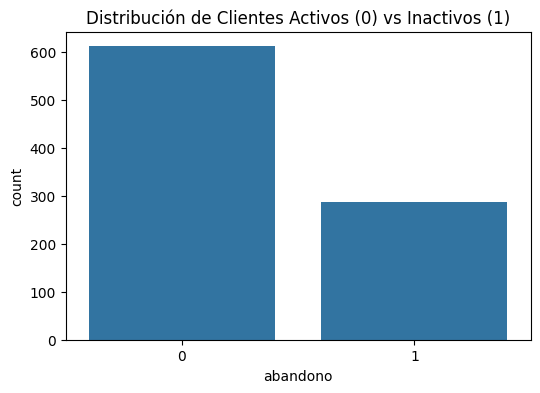

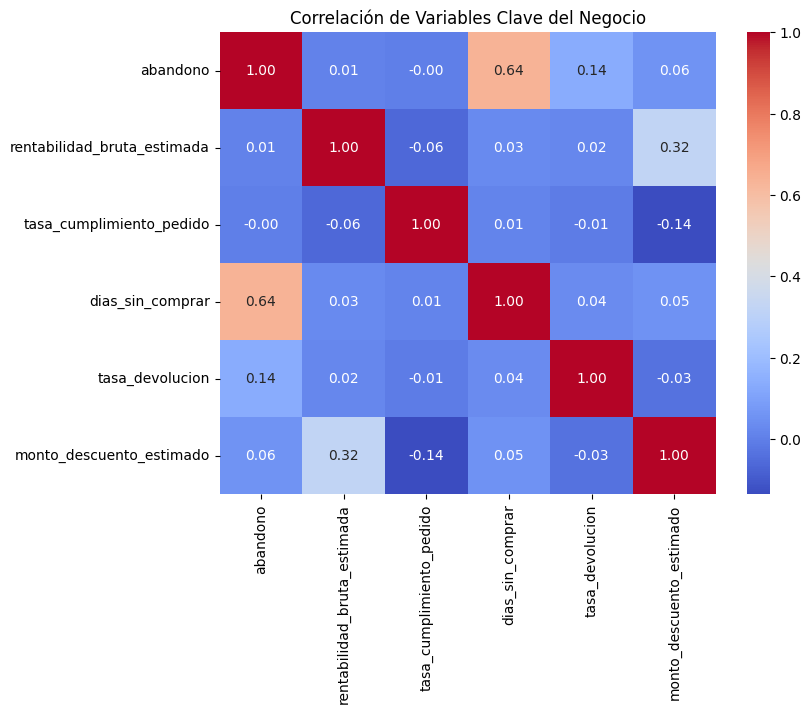

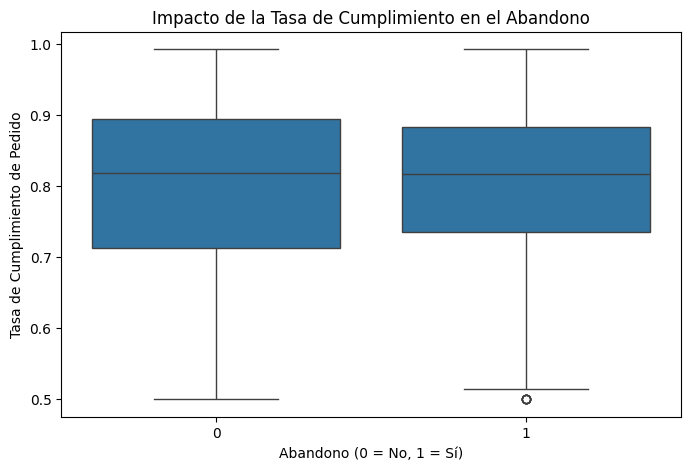


--- Se detectaron 69 outliers positivos en Rentabilidad ---
Nota: No se eliminarán, ya que pueden representar clientes estratégicos de alto volumen.


In [9]:
# EDA VISUAL Y DETECCIÓN DE OUTLIERS

# 1. Distribución de la variable objetivo (Abandono)
plt.figure(figsize=(6, 4))
sns.countplot(x='abandono', data=df)
plt.title('Distribución de Clientes Activos (0) vs Inactivos (1)')
plt.show()

# 2. Matriz de Correlación enfocada en variables clave
columnas_clave = ['abandono', 'rentabilidad_bruta_estimada', 'tasa_cumplimiento_pedido',
                  'dias_sin_comprar', 'tasa_devolucion', 'monto_descuento_estimado']

plt.figure(figsize=(8, 6))
sns.heatmap(df[columnas_clave].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de Variables Clave del Negocio')
plt.show()

# 3. Visualización de patrones (Ej: ¿La mala logística provoca abandono?)
plt.figure(figsize=(8, 5))
sns.boxplot(x='abandono', y='tasa_cumplimiento_pedido', data=df)
plt.title('Impacto de la Tasa de Cumplimiento en el Abandono')
plt.ylabel('Tasa de Cumplimiento de Pedido')
plt.xlabel('Abandono (0 = No, 1 = Sí)')
plt.show()

# 4. Detección de Outliers (Enfocada y documentada)
# Solo analizamos outliers en rentabilidad para identificar clientes como el "Casino Corporativo XYZ"
Q1 = df['rentabilidad_bruta_estimada'].quantile(0.25)
Q3 = df['rentabilidad_bruta_estimada'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers_rentabilidad = df[df['rentabilidad_bruta_estimada'] > limite_superior]
print(f"\n--- Se detectaron {len(outliers_rentabilidad)} outliers positivos en Rentabilidad ---")
print("Nota: No se eliminarán, ya que pueden representar clientes estratégicos de alto volumen.")

Modelo predictivo y evaluación



In [13]:
#Preprocesamiento de datos
y = df['abandono']
X = df.drop(columns=['abandono', 'cliente_id', 'rut_cliente', 'vendedor_id', 'fecha_ultimo_pedido', 'dias_sin_comprar'])

# Identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

# Crear pipelines de preprocesamiento
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinar preprocesadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Transformar datos
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Modelo 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_transformed, y_train)
y_pred_log = log_reg.predict(X_test_transformed)

# Validación cruzada Logistic Regression
cv_log = cross_val_score(log_reg, X_train_transformed, y_train, cv=5, scoring="roc_auc")

# Modelo 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_transformed, y_train)
y_pred_rf = rf.predict(X_test_transformed)

# Validación cruzada Random Forest
cv_rf = cross_val_score(rf, X_train_transformed, y_train, cv=5, scoring="roc_auc")

# Función para mostrar métricas
def evaluar_modelo(y_true, y_pred, nombre, cv_scores):
    print(f"--- {nombre} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred))
    print("Validación cruzada (ROC-AUC):", cv_scores.mean())
    print()

# Evaluar ambos modelos
evaluar_modelo(y_test, y_pred_log, "Logistic Regression", cv_log)
evaluar_modelo(y_test, y_pred_rf, "Random Forest", cv_rf)

--- Logistic Regression ---
Accuracy: 0.7407407407407407
Precision: 0.66
Recall: 0.38372093023255816
F1: 0.4852941176470588
ROC-AUC: 0.6456648129423661
Validación cruzada (ROC-AUC): 0.7093008241299923

--- Random Forest ---
Accuracy: 0.7444444444444445
Precision: 0.660377358490566
Recall: 0.4069767441860465
F1: 0.5035971223021583
ROC-AUC: 0.6545753286147624
Validación cruzada (ROC-AUC): 0.7053950485469288



El código realiza un pipeline de machine learning para predecir el abandono de clientes. Prepara los datos eliminados columnas irrelevantes, imputando valores nulos y aplicando transformaciones: estandarización en variables numéricas y codificación one-hot en categóricas.
Luego divide el dataset en entrenamiento y prueba, aplica el preprocesamiento y entrena dos modelos: Regresión Logística como baseline y Random Forest para capturar relaciones mas complejas. Ambos se valían con cross-validation usando la métrica ROC-AUC.
Finalmente, se evalúan los modelos con métricas de clasificación (Accuracy, precisión, Recall, F1 y ROC-AUC), permitiendo comparar su rendimiento y determinar cual predice mejor el abandono de clientes.


Comparativa de modelos

In [11]:
from sklearn.metrics import classification_report, roc_auc_score

# Predicciones con Random Forest
y_pred_rf = rf.predict(X_test_transformed)
y_proba_rf = rf.predict_proba(X_test_transformed)[:,1]

# Reporte de clasificación
print("Reporte de clasificación - Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=["Activo","Abandono"]))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Reporte de clasificación - Random Forest
              precision    recall  f1-score   support

      Activo       0.91      0.95      0.93       184
    Abandono       0.88      0.80      0.84        86

    accuracy                           0.90       270
   macro avg       0.90      0.88      0.89       270
weighted avg       0.90      0.90      0.90       270

ROC-AUC: 0.9524772497472195


El modelo Random Forest en el conjunto de prueba. Primero obtiene las predicciones (y_pred_rf) y las probabilidades de pertenecer a la clase de abandono (y_proba_rf). Luego, genera un reporte de clasificación con métricas como precisión, recall y F1-score para cada clase (“Activo” y “Abandono”), lo que permite analizar el desempeño detallado del modelo. Finalmente, calcula el ROC-AUC, que mide la capacidad de Random Forest para discriminar entre clientes que abandonan y los que permanecen activos.

--- Generando interpretación de variables con SHAP ---


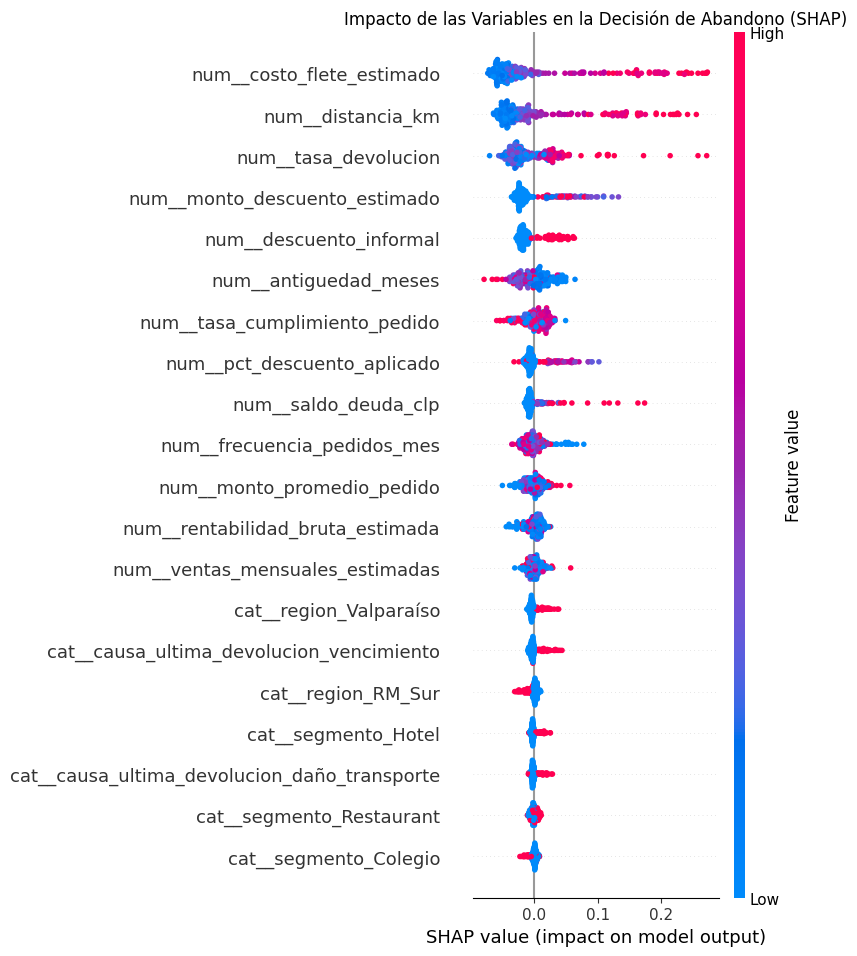

In [17]:
import shap

# 1. Recuperar nombres de columnas
feature_names = preprocessor.get_feature_names_out()

# 2. Convertir a DataFrame
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# 3. Explicar el modelo
# Usamos TreeExplainer para Random Forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_shap)

# 4. Manejo de dimensiones para clasificación binaria
# En algunas versiones shap_values es [nsamples, nfeatures, nclasses]
# En otras es una lista [array_clase0, array_clase1]
import numpy as np
if isinstance(shap_values, list):
    # Si es una lista, tomamos la clase 1 (Abandono)
    shap_val_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # Si es un array 3D, tomamos la última dimensión
    shap_val_plot = shap_values[:, :, 1]
else:
    shap_val_plot = shap_values

# 5. Graficar
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_val_plot, X_test_shap, plot_type="dot", show=False)
plt.title("Impacto de las Variables en la Decisión de Abandono (SHAP)")
plt.show()